In [4]:
# ===============================================
# CONECTAR GOOGLE DRIVE
# ===============================================

from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ===============================================
# IMPORTAR LIBRERIAS
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
# ===============================================
# CARGAR DATASET
# ===============================================

# Ruta del archivo en Google Drive
ruta = "/content/drive/MyDrive/data sets /New York City Airbnb Open Data/AB_NYC_2019.csv"

# Leer dataset con pandas
data = pd.read_csv(ruta)

# Mostrar primeras filas
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
# ===============================================
# INFORMACION DEL DATASET
# ===============================================

print("Numero de ejemplos (m):", data.shape[0])
print("Numero de caracteristicas (n):", data.shape[1])

data.info()

Numero de ejemplos (m): 48895
Numero de caracteristicas (n): 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews            

In [10]:
# ===============================================
# PREPROCESAMIENTO
# ===============================================

# Seleccionar solo columnas numericas
data_numerico = data.select_dtypes(include=[np.number])

# Mostrar dataset numerico
data_numerico.head()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,2787,40.64749,-73.97237,149,1,9,0.21,6,365
1,2595,2845,40.75362,-73.98377,225,1,45,0.38,2,355
2,3647,4632,40.80902,-73.94190,150,3,0,NaN,1,365
3,3831,4869,40.68514,-73.95976,89,1,270,4.64,1,194
4,5022,7192,40.79851,-73.94399,80,10,9,0.10,1,0


In [11]:
# ===============================================
# DEFINIR VARIABLES
# ===============================================

# Variable objetivo
y = data_numerico["price"].values

# Variables predictoras
X = data_numerico.drop("price", axis=1).values

print("Ejemplos:", X.shape[0])
print("Caracteristicas:", X.shape[1])

Ejemplos: 48895
Caracteristicas: 9


In [12]:
# ===============================================
# NORMALIZACION
# ===============================================

def normalizar(X):

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

X_norm, mu, sigma = normalizar(X)

print("Normalizacion completada")

Normalizacion completada


In [13]:
# ===============================================
# AGREGAR COLUMNA DE 1
# ===============================================

m = X_norm.shape[0]

X = np.concatenate([np.ones((m,1)), X_norm], axis=1)

In [14]:
# ===============================================
# INICIALIZAR PARAMETROS
# ===============================================

n = X.shape[1]

theta = np.zeros(n)

print("Theta inicial:", theta)

Theta inicial: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
# ===============================================
# FUNCION DE COSTO
# ===============================================

def calcularCosto(X,y,theta):

    m = len(y)

    pred = X.dot(theta)

    error = pred - y

    J = (1/(2*m)) * np.sum(error**2)

    return J

In [16]:
# ===============================================
# GRADIENTE DESCENDENTE
# ===============================================

def gradienteDescendente(X,y,theta,alpha,iteraciones):

    m = len(y)

    historial = []

    for i in range(iteraciones):

        pred = X.dot(theta)

        error = pred - y

        theta = theta - (alpha/m)*(X.T.dot(error))

        costo = calcularCosto(X,y,theta)

        historial.append(costo)

    return theta, historial

In [17]:
# ===============================================
# ENTRENAR MODELO
# ===============================================

alpha = 0.01
iteraciones = 500

theta, historial = gradienteDescendente(X,y,theta,alpha,iteraciones)

print("Theta final:")
print(theta)

Theta final:
[nan nan nan nan nan nan nan nan nan nan]


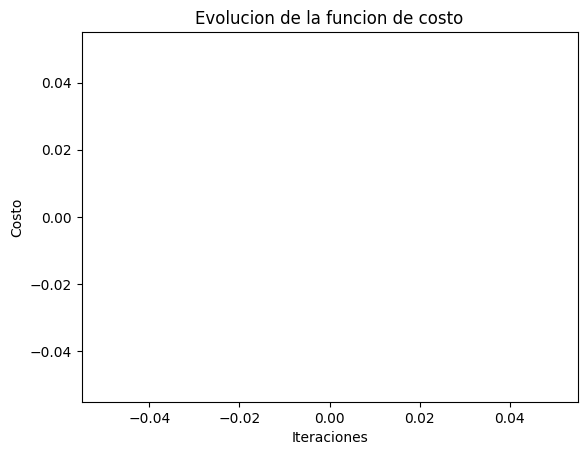

In [18]:
# ===============================================
# GRAFICO DE LA FUNCION DE COSTO
# ===============================================

plt.figure()

plt.plot(historial)

plt.xlabel("Iteraciones")
plt.ylabel("Costo")

plt.title("Evolucion de la funcion de costo")

plt.show()

In [19]:
# ===============================================
# REALIZAR PREDICCIONES
# ===============================================

predicciones = X.dot(theta)

print("Primeras 100 predicciones")

print(predicciones[:100])

Primeras 100 predicciones
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]


In [20]:
# ===============================================
# ERROR FINAL DEL MODELO
# ===============================================

error_final = calcularCosto(X,y,theta)

print("Error final del modelo:", error_final)

Error final del modelo: nan
